In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [3]:
query = select(Feedback.json, Feedback.datetime).filter(
        Feedback.key_name == 'votes',
        Feedback.datetime >= datetime(2024, 9, 1),
        Feedback.datetime <= datetime(2024, 10, 1))
df = pd.read_sql_query(query, session.connection())

In [4]:
def map_votes(row):
    result = dict()
    for vote, counts in row['data'].items():
        if vote == 'map':
            for map_name, count in counts.items():
                result[map_name] = count
    return result

In [5]:
normalized = df.join(pd.json_normalize(df.json.map(map_votes))).drop(['json'], axis=1)

In [8]:
shipnames = ['NSS Cyberiad (Cyberiad)', 'NSS Farragus (CereStation)',
       'NSS Cerebron (MetaStation)', 'NSS Kerberos (Delta)',
       'NSS Diagoras (EmeraldStation)']

In [9]:
summed = normalized.resample('D', on='datetime')[list(shipnames)].sum()

In [10]:
normalized.columns[1:]

Index(['NSS Farragus (CereStation)', 'NSS Cerebron (MetaStation)',
       'NSS Cyberiad (Cyberiad)', 'NSS Kerberos (Delta)',
       'NSS Diagoras (EmeraldStation)'],
      dtype='object')

In [11]:
cols = [str(x) for x in normalized.columns[1:]]
summed[cols] = summed[cols].div(summed[cols].sum(axis=1), axis=0).multiply(100)

In [12]:
dropped_random_days = summed[summed['NSS Cyberiad (Cyberiad)'].notna()]

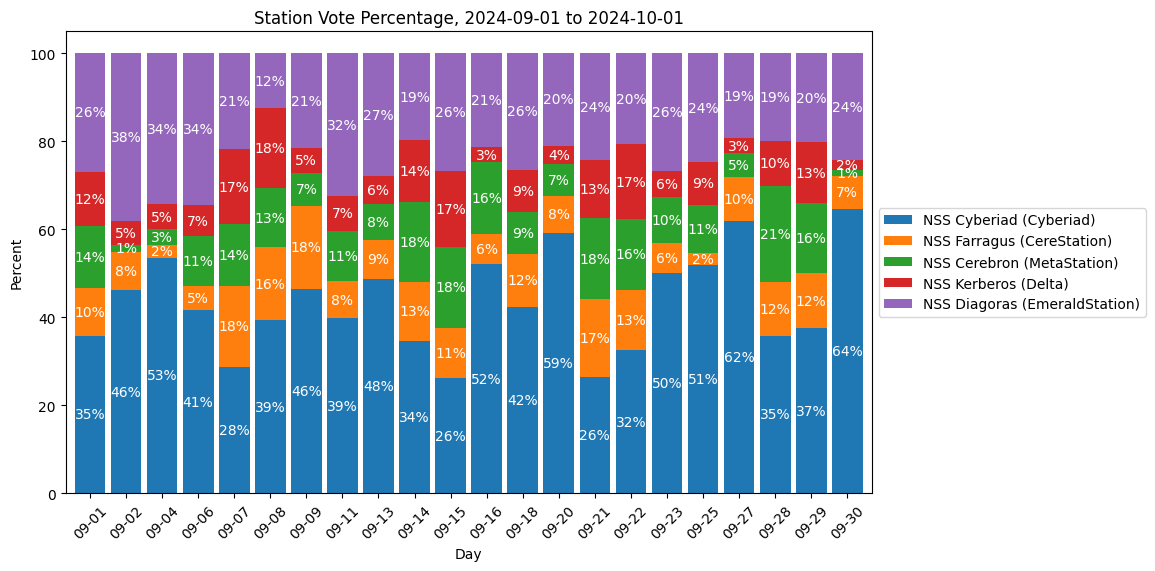

In [15]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 6)

plot = dropped_random_days.plot(kind='bar', stacked=True, ax=ax, width=0.85)
for c in ax.containers:
    labels = [f"{int(v.get_height())}%" if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white')
ax.set_xticklabels([x.strftime("%m-%d") for x in dropped_random_days.index], rotation=45)
plt.title("Station Vote Percentage, 2024-09-01 to 2024-10-01")
ax.set_xlabel('Day')
ax.set_ylabel('Percent')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('emerald_intro_week.png')